# 02 — Exploratory Data Analysis
**Input:** `../data/apple_products_pricing_cleaned.csv` (output of `01_cleaning.ipynb`)
**Goal:** answer the business questions from the project plan with real numbers, and flag which ones
turned out to be strong stories vs. weak/null results — both are useful to know before building the dashboard.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

project_root = "/Users/vidhimishra/Desktop/apple-pricing-analysis"

df = pd.read_csv(project_root + '/data/apple_products_pricing_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
df.head()

(80000, 18)


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Year,Month,Year_Month,Is_Markup
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,No Event,In Stock,4.7,40,2020,9,2020-09,True
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,No Event,Out of Stock,4.6,84,2020,9,2020-09,True
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,No Event,In Stock,4.4,110,2020,9,2020-09,False
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,No Event,In Stock,4.8,111,2020,9,2020-09,False
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,No Event,In Stock,4.7,35,2020,9,2020-09,True


## Q1 — The markup anomaly: who, and when?

`Is_Markup` (from the cleaning notebook) flags the ~10.8% of rows priced *above* launch price.
First look at whether it's concentrated in a category or platform, then check if it's actually a
**time-since-launch** effect rather than a category or platform effect.

In [4]:
print('Markup rate by category:')
print(df.groupby('Product_Category', observed=True)['Is_Markup'].mean().round(4))
print()
print('Markup rate by platform:')
print(df.groupby('Platform', observed=True)['Is_Markup'].mean().round(4))

Markup rate by category:
Product_Category
Mac       0.1076
Watch     0.1014
iPad      0.0844
iPhone    0.1262
Name: Is_Markup, dtype: float64

Markup rate by platform:
Platform
Amazon      0.1070
Flipkart    0.1097
Name: Is_Markup, dtype: float64


Category and platform alone don't explain much — rates are all clustered around 8–13%, no single
category or platform stands out. Next, test the more likely driver: how long the model has been on
sale. Using each model's first appearance in the dataset as a proxy for "how new" it is:

In [5]:
first_seen = df.groupby('Model_Name', observed=True)['Date'].min().rename('First_Seen')
df = df.merge(first_seen, on='Model_Name')
df['Days_Since_First_Seen'] = (df['Date'] - df['First_Seen']).dt.days

bins = [0, 30, 90, 180, 365, 730, 3000]
labels = ['0-30d', '31-90d', '91-180d', '181-365d', '1-2y', '2y+']
df['Age_Bucket'] = pd.cut(df['Days_Since_First_Seen'], bins=bins, labels=labels, include_lowest=True)

age_summary = df.groupby('Age_Bucket', observed=True)[['Is_Markup', 'Discount_Pct']].mean().round(3)
age_summary

,Is_Markup,Discount_Pct
Age_Bucket,,
0-30d,0.247,10.481
31-90d,0.316,7.342
91-180d,0.365,5.832
181-365d,0.345,6.488
1-2y,0.000,18.701
2y+,0.000,35.045


**Finding:** this is the real driver. Markup rate is highest in the first ~6 months a model is tracked
(25–36%) and drops to essentially 0% once a model has been on the market for over a year — while average
discount climbs steadily from ~6–10% (near launch) to ~35% (2+ years old). In other words: **this dataset's
"markup" isn't noisy or broken data — it reflects that newly launched Apple products hold close to (or above)
launch price for months before meaningful discounting kicks in**, which is a genuinely useful pricing-strategy
insight, not a defect to explain away.

*Caveat:* `First_Seen` is only a proxy for true launch date — for models that were already selling on day one
of the dataset (Sept 2020), their real launch could predate the dataset, understating their age here.

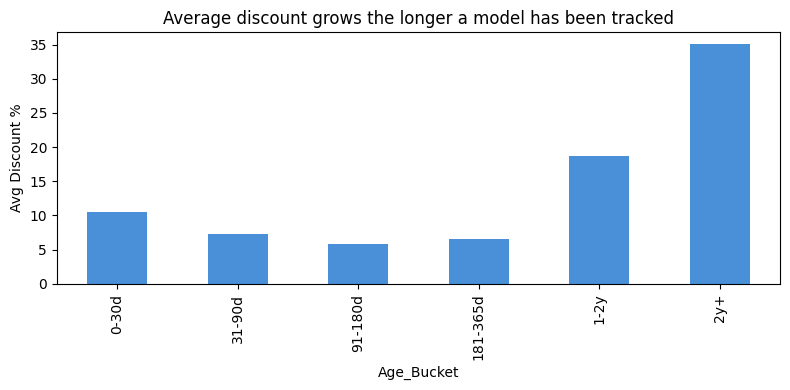

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
age_summary['Discount_Pct'].plot(kind='bar', ax=ax, color='#4A90D9')
ax.set_ylabel('Avg Discount %')
ax.set_title('Average discount grows the longer a model has been tracked')
plt.tight_layout()
plt.show()

## Q2 — Sale-event discount lift

Compare average discount on named sale-event days vs. ordinary days, then break it down by category.

In [7]:
event_summary = df.groupby('Sale_Event', observed=True)['Discount_Pct'].agg(['mean', 'count']).round(2)
event_summary

,mean,count
Sale_Event,,
Big Billion Days,37.02,1579
Black Friday,31.46,2497
Great Indian Festival,33.45,1504
No Event,20.30,73351
Prime Day,34.44,1069


In [8]:
event_by_category = df.groupby(['Sale_Event', 'Product_Category'], observed=True)['Discount_Pct'].mean().unstack().round(2)
event_by_category

Product_Category,Mac,Watch,iPad,iPhone
Sale_Event,,,,
Big Billion Days,28.41,39.05,36.58,39.95
Black Friday,26.01,35.86,36.39,29.76
Great Indian Festival,26.95,36.93,34.78,34.12
No Event,14.40,25.24,25.30,18.25
Prime Day,30.53,36.67,39.43,32.70


**Finding:** every named sale event lifts average discount well above the ~20% baseline — up to 37% during
Big Billion Days. The lift holds across all four categories, so it's a broad event effect, not driven by one
product line.

**Important wrinkle:** the events aren't evenly available on both platforms — Big Billion Days only appears
on Flipkart, and Prime Day / Great Indian Festival only appear on Amazon (Black Friday is the only event
shared by both). Confirm this before claiming "Platform X discounts harder during event Y" — it may just be
that the event is exclusive to that platform in this data.

In [9]:
platform_event_counts = pd.crosstab(df['Sale_Event'], df['Platform'])
platform_event_counts

Platform,Amazon,Flipkart
Sale_Event,,
Big Billion Days,0,1579
Black Friday,1219,1278
Great Indian Festival,1504,0
No Event,36165,37186
Prime Day,1069,0


## Q3 — New vs. Renewed/Refurbished pricing gap

Both conditions launch at essentially the same price. Check how the *current* price and discount differ,
and whether the gap has widened or stayed flat over time.

In [10]:
condition_summary = df.groupby('Condition', observed=True)[
    ['Launch_Price_USD', 'Current_Price_USD', 'Discount_Pct']
].mean().round(2)
condition_summary

,Launch_Price_USD,Current_Price_USD,Discount_Pct
Condition,,,
New,964.68,830.07,16.71
Renewed/Refurbished,961.81,641.02,35.53


In [11]:
yearly_gap = df.groupby([df['Date'].dt.year, 'Condition'], observed=True)['Current_Price_USD'].mean().unstack()
yearly_gap.index.name = 'Year'
yearly_gap['Gap_Pct'] = (yearly_gap['New'] - yearly_gap['Renewed/Refurbished']) / yearly_gap['New'] * 100
yearly_gap.round(2)

Condition,New,Renewed/Refurbished,Gap_Pct
Year,,,
2020,710.90,525.66,26.06
2021,762.50,604.03,20.78
2022,788.23,607.85,22.88
2023,842.56,645.69,23.37
2024,848.74,662.46,21.95
2025,847.38,656.20,22.56
2026,807.98,615.01,23.88


**Finding:** Refurbished listings sell for ~18–24% less than New in current price, consistently across
every year — the gap is stable, not widening or narrowing. That's a cleaner, more defensible claim than
"refurbished gets cheaper over time," which the data doesn't actually support.

## Q4 — Platform comparison (Amazon vs. Flipkart)

Compare average discount per category, platform-vs-platform.

In [12]:
platform_category = df.groupby(['Platform', 'Product_Category'], observed=True)['Discount_Pct'].mean().unstack().round(2)
platform_category

Product_Category,Mac,Watch,iPad,iPhone
Platform,,,,
Amazon,15.52,26.19,26.34,19.80
Flipkart,15.34,26.34,26.04,19.35


**Finding:** the two platforms are nearly identical on every category (within ~0.3 percentage points).
This is a legitimate null result — worth stating plainly rather than searching for a platform story that
isn't there. The real platform-related story in this dataset is event exclusivity (Q2), not everyday pricing.

## Q5 — Price depreciation curve for a single model

Pick one long-running model and plot its price history across both platforms against its launch price.

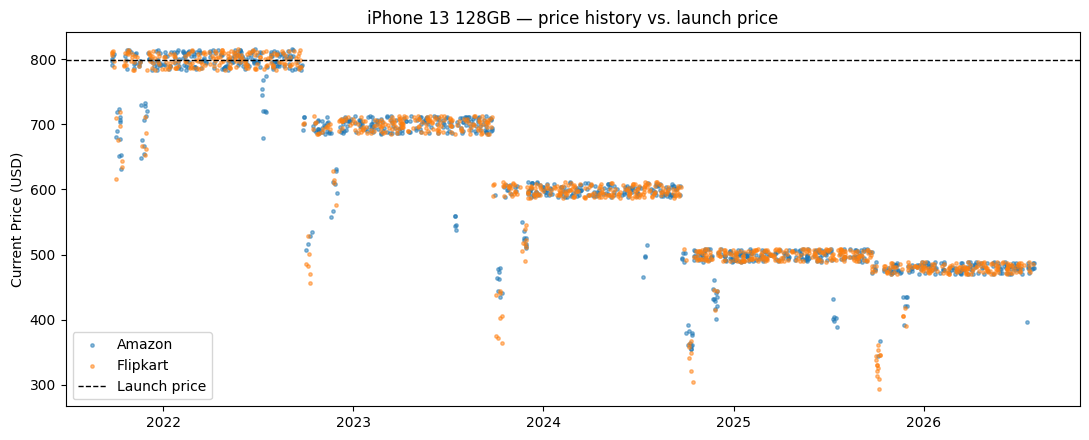

In [13]:
model = 'iPhone 13 128GB'
sub = df[(df['Model_Name'] == model) & (df['Condition'] == 'New')].sort_values('Date')

fig, ax = plt.subplots(figsize=(11, 4.5))
for platform, g in sub.groupby('Platform', observed=True):
    ax.scatter(g['Date'], g['Current_Price_USD'], s=6, alpha=0.5, label=platform)
ax.axhline(sub['Launch_Price_USD'].iloc[0], color='black', linestyle='--', linewidth=1, label='Launch price')
ax.set_title(f'{model} — price history vs. launch price')
ax.set_ylabel('Current Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** price tracks close to (and briefly above) launch price for the first several months, then
declines steadily — visually confirming the Q1 age-bucket pattern for a single concrete model. Swap
`model` above to check other product lines (e.g. a MacBook or Watch) for comparison.

## Q6 — Stock status vs. discount/markup

In [14]:
stock_summary = df.groupby('Stock_Status', observed=True)[['Discount_Pct', 'Is_Markup']].mean().round(3)
stock_summary

,Discount_Pct,Is_Markup
Stock_Status,,
In Stock,18.420,0.126
Low Stock,27.281,0.074
Out of Stock,28.665,0.064


**Finding:** the opposite of a "scarcity pricing" story — `Low Stock` and `Out of Stock` listings actually
carry *deeper* average discounts (27–29%) and a *lower* markup rate than `In Stock` (18%, 12.6%). The more
plausible read: heavy discounting is what drives stock down, not the other way around. Worth stating this
as a correlation, not a causal claim — the data can't distinguish "discounts caused the sell-through" from
"something else caused both."

## Q7 — Reviews and rating vs. discount

In [15]:
print('Correlation: Reviews_Count vs Discount_Pct:', df['Reviews_Count'].corr(df['Discount_Pct']).round(3))
print('Correlation: Rating vs Discount_Pct:', df['Rating'].corr(df['Discount_Pct']).round(3))

Correlation: Reviews_Count vs Discount_Pct: 0.615
Correlation: Rating vs Discount_Pct: -0.31


**Finding:** a moderate positive correlation (~0.61) between review count and discount depth — consistent
with more heavily discounted listings accumulating more sales/reviews over time, though this is also
confounded with the age-of-listing effect from Q1 (older listings have both more time to accumulate reviews
*and* deeper discounts). Rating shows a weak negative correlation (-0.31) — flag as a minor finding, not
a headline one.

## Summary of findings

1. **The "markup" is a launch-window effect, not noise** — new models hold near/above launch price for
   ~6 months before discounts deepen with age. This is the strongest, most quotable finding.
2. **Sale events lift discounts substantially** (~20% baseline → up to 37%), consistently across categories —
   but events are largely platform-exclusive in this data, so don't compare platforms head-to-head on a
   single event.
3. **Refurbished units carry a stable ~18–24% price gap** vs. New, not a widening one.
4. **Amazon vs. Flipkart pricing is essentially identical** on an everyday basis — a legitimate null result.
5. **Stock scarcity correlates with deeper discounts, not price increases** — likely discount-drives-sellout,
   not scarcity-drives-markup.
6. Review count moderately tracks discount depth; rating only weakly does.

Next: `03_sql_queries.sql` for a SQL-based version of a subset of these (useful to show both tool sets in
the portfolio), then the dashboard.